# SEHS5052 Topic E — Explainable AI for SOC (CICIDS-2017)

This notebook is a **fully self-contained** implementation focused on the CICIDS-2017 dataset, and is designed to run in both local and Colab environments. It assumes the dataset is already extracted into CSV files (no automatic ZIP extraction).

### What You Will Get
- End-to-end training and evaluation: Baseline (Logistic Regression) + Black-box (Random Forest)
- Explainability outputs: SHAP global importance, SHAP summary/waterfall, and LIME local explanations
- SOC decision-support artifacts: case report, SHAP/LIME comparison table, metrics, and figures
- Unified output location: `OUTPUT_DIR` (default: `artifacts/`)

### Recommended Run Order
1. Configure paths and parameters (`DATA_DIR` / `CICIDS_PATH` / sampling + model settings)
2. Run the environment detection/helper cell (local or Colab)
3. Run module definition cells in order
4. Run the end-to-end execution cell to generate all outputs

### Colab Usage
1. Upload this notebook and make sure the dataset folder is accessible (direct upload or Google Drive)
2. Set `DATA_DIR` or `CICIDS_PATH` in the configuration cell
3. Run all cells; outputs are written to `OUTPUT_DIR`, and key tables/plots are shown inline

The section structure aligns with Report Part 2–4 for direct report writing support.


In [1]:
%pip install -q numpy pandas scikit-learn matplotlib seaborn shap lime


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from __future__ import annotations

import json
import logging
import time
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Ensure notebook plots are rendered inline.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

LOG_LEVEL = "DEBUG"
logging.basicConfig(level=getattr(logging, LOG_LEVEL.upper(), logging.DEBUG), format="%(asctime)s %(levelname)s %(name)s %(message)s", force=True)

# Keep our app logs verbose, but silence noisy third-party debug logs.
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("matplotlib.font_manager").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)
logging.getLogger("numba").setLevel(logging.WARNING)

# --- Colab / local paths ---
LOCAL_DATA_DIR = "data/cicids/TrafficLabelling"
COLAB_DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/5022_Group Project/data/cicids/TrafficLabelling"

try:
    import google.colab  # type: ignore

    IN_COLAB = True
except Exception:
    IN_COLAB = False

DATA_DIR = COLAB_DATA_DIR if IN_COLAB else LOCAL_DATA_DIR
print(f"Using DATA_DIR: {DATA_DIR}")

# Logging/visualization controls for notebook runs.
VERBOSE_LOGGING = True
SHOW_INLINE_PLOTS = True
SHOW_INLINE_TABLES = True

CICIDS_PATH: str | None = None  # e.g. "/content/drive/MyDrive/.../some_cicids.csv"
CICIDS_LABEL_COL = "Label"
MAX_ROWS = 30_000
SAMPLE_SIZE = 12_000
CLASS_BALANCE_RETRY_CAP = 300_000
RF_N_ESTIMATORS = 120
RF_MAX_DEPTH = 20
RF_MIN_SAMPLES_LEAF = 2
DISABLE_LIME = False
OUTPUT_DIR = "artifacts"
LOG_FILE: str | None = None  # e.g. str(Path(OUTPUT_DIR) / "run.log")


Using DATA_DIR: data/cicids/TrafficLabelling


In [3]:
# Optional: environment helper for Colab/local execution

try:
    import google.colab  # type: ignore

    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive  # type: ignore

    mount_point = Path("/content/drive")
    if not mount_point.exists() or not any(mount_point.iterdir()):
        drive.mount(str(mount_point))
    else:
        print("Google Drive already mounted.")

    data_dir_path = Path(DATA_DIR)
    if data_dir_path.exists():
        print(f"Using Colab DATA_DIR: {DATA_DIR}")
    else:
        print(f"Warning: DATA_DIR not found in Colab: {DATA_DIR}")

    # Optional: set CICIDS_PATH directly if you want a specific CSV.
    # CICIDS_PATH = "/content/drive/MyDrive/.../your_file.csv"
else:
    data_dir_path = Path(DATA_DIR)
    if data_dir_path.exists():
        print(f"Using local DATA_DIR: {DATA_DIR}")
    else:
        print(f"Warning: local DATA_DIR not found: {DATA_DIR}")


## Report Part 2 — Dataset description and preprocessing

Matches **Written Report Part 2**: CICIDS load, cleaning, stratified sampling, train/val/test split.


In [4]:
"""Data loading and preprocessing helpers for Topic E experiments."""

from __future__ import annotations

from dataclasses import dataclass
import logging
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


RANDOM_STATE = 42
logger = logging.getLogger(__name__)


@dataclass
class DatasetBundle:
    """Container that keeps features and labels together."""

    X: pd.DataFrame
    y: pd.Series
    attack_type: pd.Series


def load_csv(path_or_url: str, nrows: Optional[int] = None) -> pd.DataFrame:
    """Load a CSV file from local path or URL."""
    logger.debug("Loading CSV from %s (nrows=%s)", path_or_url, nrows)
    try:
        df = pd.read_csv(path_or_url, nrows=nrows, low_memory=False)
    except UnicodeDecodeError:
        logger.warning("UTF-8 decode failed for %s; retrying with latin1.", path_or_url)
        df = pd.read_csv(path_or_url, nrows=nrows, encoding="latin1", low_memory=False)
    logger.debug("Loaded dataframe shape from %s: %s", path_or_url, df.shape)
    return df


def unify_binary_labels(
    df: pd.DataFrame,
    label_col: str,
    benign_tokens: Tuple[str, ...] = ("benign", "normal"),
) -> DatasetBundle:
    """Map dataset labels to binary labels: benign=0, attack=1."""
    if label_col not in df.columns:
        # CIC/UNSW CSVs often contain extra spaces in header names.
        normalized_map = {str(c).strip().lower(): c for c in df.columns}
        resolved = normalized_map.get(label_col.strip().lower())
        if resolved is None:
            raise ValueError(f"Label column '{label_col}' not found.")
        label_col = resolved

    attack_type = df[label_col].astype(str)
    norm = attack_type.str.strip().str.lower()
    benign_mask = norm.isin(set(benign_tokens))
    y = (~benign_mask).astype(int)

    X = df.drop(columns=[label_col]).copy()
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    logger.info(
        "Mapped labels using '%s': benign=%d attack=%d",
        label_col,
        int((y == 0).sum()),
        int((y == 1).sum()),
    )
    return DatasetBundle(X=X, y=y, attack_type=attack_type)


def basic_cleaning(X: pd.DataFrame, missing_ratio_threshold: float = 0.4) -> pd.DataFrame:
    """Drop highly missing columns and remove duplicate rows."""
    cleaned = X.copy()
    missing_ratio = cleaned.isna().mean()
    to_drop = missing_ratio[missing_ratio > missing_ratio_threshold].index.tolist()
    if to_drop:
        cleaned = cleaned.drop(columns=to_drop)
    cleaned = cleaned.drop_duplicates()
    logger.info(
        "Basic cleaning completed: input=%s output=%s dropped_cols=%d",
        X.shape,
        cleaned.shape,
        len(to_drop),
    )
    return cleaned


def split_train_val_test(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.15,
    val_size: float = 0.15,
    random_state: int = RANDOM_STATE,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """Stratified train/val/test split."""
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    val_ratio_in_train_val = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=val_ratio_in_train_val,
        stratify=y_train_val,
        random_state=random_state,
    )
    logger.info("Split sizes -> train=%d val=%d test=%d", len(X_train), len(X_val), len(X_test))
    return X_train, X_val, X_test, y_train, y_val, y_test


def sample_dataset_bundle(
    bundle: DatasetBundle,
    sample_size: Optional[int],
    random_state: int = RANDOM_STATE,
) -> DatasetBundle:
    """
    Randomly sample a subset of rows once, then reuse for all models.
    Stratified sampling is used when both classes exist.
    """
    if sample_size is None or sample_size <= 0 or sample_size >= len(bundle.X):
        return bundle

    indices = np.arange(len(bundle.X))
    y = bundle.y.reset_index(drop=True)
    stratify = y if y.nunique() > 1 else None
    sampled_idx, _ = train_test_split(
        indices,
        train_size=sample_size,
        random_state=random_state,
        stratify=stratify,
    )
    sampled_idx = np.sort(sampled_idx)
    logger.info(
        "Random sampled dataset: original=%d sampled=%d stratified=%s",
        len(bundle.X),
        sample_size,
        "yes" if stratify is not None else "no",
    )
    return DatasetBundle(
        X=bundle.X.iloc[sampled_idx].reset_index(drop=True),
        y=bundle.y.iloc[sampled_idx].reset_index(drop=True),
        attack_type=bundle.attack_type.iloc[sampled_idx].reset_index(drop=True),
    )


def align_common_columns(df_a: pd.DataFrame, df_b: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Keep only common columns for cross-dataset evaluation."""
    common = sorted(set(df_a.columns).intersection(df_b.columns))
    if not common:
        raise ValueError("No common columns found between datasets.")
    return df_a[common].copy(), df_b[common].copy()


def build_synthetic_dataset(n_samples: int = 2000, random_state: int = RANDOM_STATE) -> DatasetBundle:
    """Build synthetic tabular data for smoke tests and quick demo runs."""
    rng = np.random.default_rng(seed=random_state)
    X = pd.DataFrame(
        {
            "FlowDuration": rng.normal(200, 40, n_samples),
            "TotFwdPkts": rng.normal(20, 6, n_samples),
            "TotBwdPkts": rng.normal(18, 7, n_samples),
            "PktLenMean": rng.normal(500, 120, n_samples),
            "Protocol": rng.choice(["TCP", "UDP", "ICMP"], n_samples, p=[0.7, 0.25, 0.05]),
            "Flag": rng.choice(["S0", "SF", "REJ"], n_samples, p=[0.15, 0.75, 0.10]),
        }
    )
    score = (
        0.007 * X["FlowDuration"]
        + 0.04 * X["TotFwdPkts"]
        + 0.03 * X["TotBwdPkts"]
        + 0.002 * X["PktLenMean"]
        + (X["Protocol"] == "ICMP").astype(int) * 1.6
        + (X["Flag"] == "S0").astype(int) * 1.2
        + rng.normal(0, 0.8, n_samples)
    )
    y = (score > np.quantile(score, 0.68)).astype(int)
    attack_type = pd.Series(np.where(y == 1, "Attack", "Benign"), name="Label")
    return DatasetBundle(X=X, y=pd.Series(y, name="y"), attack_type=attack_type)


def _dataset_dir(data_root: str | Path, dataset_name: str) -> Path:
    root = Path(data_root)
    return root / dataset_name.lower()


def _find_first_csv(target_dir: Path, dataset_name: Optional[str] = None) -> Optional[Path]:
    if not target_dir.exists():
        return None
    csvs = sorted(target_dir.rglob("*.csv"))
    if not csvs:
        return None

    if dataset_name and dataset_name.lower() == "cicids":
        # Prefer MachineLearningCSV-derived files over GeneratedLabelledFlows files.
        preferred = [p for p in csvs if "machinelearning" in str(p).lower()]
        if preferred:
            return preferred[0]
    return csvs[0]


def ensure_dataset_csv(
    dataset_name: str,
    data_root: str | Path = "data",
    preferred_path: Optional[str] = None,
) -> Optional[str]:
    """
    Resolve dataset CSV path from:
    1) preferred_path if exists (CSV only)
    2) existing CSV files under data/<dataset_name>/

    Note:
    - ZIP extraction is intentionally disabled.
    - Datasets are expected to be pre-extracted by the user.
    """
    data_root_path = Path(data_root)
    data_root_path.mkdir(parents=True, exist_ok=True)

    if preferred_path:
        path_obj = Path(preferred_path)
        if path_obj.exists():
            logger.info("Using preferred dataset path: %s", path_obj)
            if path_obj.suffix.lower() == ".csv":
                return str(path_obj)
            logger.warning("Preferred path exists but is not a CSV: %s", path_obj)
            return None

    dataset_dir = _dataset_dir(data_root_path, dataset_name)
    dataset_dir.mkdir(parents=True, exist_ok=True)

    discovered = _find_first_csv(dataset_dir, dataset_name=dataset_name)
    if discovered:
        logger.info("Found existing dataset CSV: %s", discovered)
        return str(discovered)
    logger.info("No CSV found in %s. Please pre-extract dataset files first.", dataset_dir)
    return None


## Report Part 3 — AI model design and implementation

### Baseline and black-box models

This section implements model training and evaluation with a paired design: an interpretable baseline plus a stronger black-box model.

### What The Code Below Does
- Preprocessing pipeline: numeric features (imputation + scaling) and categorical features (imputation + one-hot encoding)
- Baseline model: `LogisticRegression` for interpretability and comparison
- Black-box model: `RandomForestClassifier` as the main performance model
- Threshold selection: searches the validation set for best F1 threshold (instead of fixed 0.5)
- Metrics: Accuracy / Precision / Recall / F1 / ROC-AUC + Confusion Matrix

### Key Outputs
- For each model: trained `pipeline`, best threshold, validation metrics, confusion matrix
- Reusable `evaluate_on_split()` for consistent train/val/test evaluation


In [5]:
"""Model training and evaluation helpers."""

from __future__ import annotations

from dataclasses import dataclass
import logging
from typing import Dict, Tuple

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


RANDOM_STATE = 42
logger = logging.getLogger(__name__)


@dataclass
class ModelArtifacts:
    name: str
    pipeline: Pipeline
    threshold: float
    metrics: Dict[str, float]
    confusion_matrix: np.ndarray


def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """Build preprocessing pipeline for mixed tabular features."""
    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    numeric_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ]
    )


def select_threshold_by_f1(y_true: pd.Series, y_prob: np.ndarray) -> float:
    """Find probability threshold that maximizes F1 on validation set."""
    best_threshold = 0.5
    best_f1 = -1.0
    for threshold in np.linspace(0.1, 0.9, 81):
        pred = (y_prob >= threshold).astype(int)
        score = f1_score(y_true, pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = float(threshold)
    return best_threshold


def compute_metrics(
    y_true: pd.Series,
    y_prob: np.ndarray,
    threshold: float,
) -> Tuple[Dict[str, float], np.ndarray]:
    """Compute required classification metrics."""
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
    }
    cm = confusion_matrix(y_true, y_pred)
    return metrics, cm


def train_baseline(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
) -> ModelArtifacts:
    """Train baseline logistic regression model."""
    logger.info("Training baseline LogisticRegression model.")
    preprocessor = build_preprocessor(X_train)
    model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    val_prob = pipe.predict_proba(X_val)[:, 1]
    threshold = select_threshold_by_f1(y_val, val_prob)
    metrics, cm = compute_metrics(y_val, val_prob, threshold)
    logger.info("Baseline trained. threshold=%.3f metrics=%s", threshold, metrics)
    return ModelArtifacts("logistic_regression", pipe, threshold, metrics, cm)


def train_blackbox(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    n_estimators: int = 120,
    max_depth: int | None = 20,
    min_samples_leaf: int = 2,
) -> ModelArtifacts:
    """Train black-box model (RF default)."""
    logger.info(
        "Training black-box RandomForest model (n_estimators=%d, max_depth=%s, min_samples_leaf=%d).",
        n_estimators,
        str(max_depth),
        min_samples_leaf,
    )
    preprocessor = build_preprocessor(X_train)
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        n_jobs=-1,
    )
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    val_prob = pipe.predict_proba(X_val)[:, 1]
    threshold = select_threshold_by_f1(y_val, val_prob)
    metrics, cm = compute_metrics(y_val, val_prob, threshold)
    logger.info("Black-box trained. threshold=%.3f metrics=%s", threshold, metrics)
    return ModelArtifacts("random_forest", pipe, threshold, metrics, cm)


def evaluate_on_split(
    model_pipe: Pipeline,
    threshold: float,
    X: pd.DataFrame,
    y: pd.Series,
) -> Tuple[Dict[str, float], np.ndarray, np.ndarray]:
    """Evaluate trained model on a dataset split."""
    probs = model_pipe.predict_proba(X)[:, 1]
    metrics, cm = compute_metrics(y, probs, threshold)
    logger.info("Evaluation metrics=%s", metrics)
    return metrics, cm, probs


### Explainability — SHAP and LIME


In [6]:
"""SHAP/LIME utilities for SOC explainability workflow."""

from __future__ import annotations

from dataclasses import dataclass
import logging
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

logger = logging.getLogger(__name__)


@dataclass
class ExplainabilityArtifacts:
    shap_global: Optional[pd.DataFrame]
    shap_local_top_features: Dict[int, List[Tuple[str, float]]]
    lime_local_top_features: Dict[int, List[Tuple[str, float]]]
    feature_names: List[str]
    shap_summary_plot: Optional[str]
    shap_waterfall_plots: Dict[int, str]


def _extract_transformed_space(
    model_pipe: Pipeline,
    X_train: pd.DataFrame,
    X_samples: pd.DataFrame,
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    preprocessor = model_pipe.named_steps["preprocessor"]
    model = model_pipe.named_steps["model"]
    X_train_t = preprocessor.transform(X_train)
    X_samples_t = preprocessor.transform(X_samples)
    feature_names = preprocessor.get_feature_names_out().tolist()
    if hasattr(X_train_t, "toarray"):
        X_train_t = X_train_t.toarray()
    else:
        X_train_t = np.asarray(X_train_t)
    if hasattr(X_samples_t, "toarray"):
        X_samples_t = X_samples_t.toarray()
    else:
        X_samples_t = np.asarray(X_samples_t)
    X_train_t = X_train_t.astype(np.float64, copy=False)
    X_samples_t = X_samples_t.astype(np.float64, copy=False)
    return X_train_t, X_samples_t, feature_names


def _compute_shap(
    model_pipe: Pipeline,
    X_train: pd.DataFrame,
    X_samples: pd.DataFrame,
    sample_ids: List[int],
    top_k: int = 8,
    max_global_samples: int = 4000,
) -> Tuple[Optional[pd.DataFrame], Dict[int, List[Tuple[str, float]]], List[str]]:
    try:
        import shap
    except Exception as exc:
        logger.warning("SHAP unavailable: %s", exc)
        return None, {}, []

    X_train_t, X_samples_t, feature_names = _extract_transformed_space(model_pipe, X_train, X_samples)
    model = model_pipe.named_steps["model"]
    logger.info("Running SHAP explainability for %d samples (top_k=%d).", len(sample_ids), top_k)

    explainer = shap.TreeExplainer(model)
    rng = np.random.default_rng(42)
    if X_samples_t.shape[0] > max_global_samples:
        chosen = rng.choice(X_samples_t.shape[0], size=max_global_samples, replace=False)
        X_global = X_samples_t[chosen]
    else:
        X_global = X_samples_t

    shap_values_global = explainer.shap_values(X_global)
    if isinstance(shap_values_global, list):
        shap_class_global = np.asarray(shap_values_global[-1])
    else:
        shap_class_global = np.asarray(shap_values_global)
        if shap_class_global.ndim == 3:
            shap_class_global = shap_class_global[:, :, -1]

    mean_abs = np.mean(np.abs(shap_class_global), axis=0)
    shap_global = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs}).sort_values(
        "mean_abs_shap", ascending=False
    )

    local = {}
    for sid in sample_ids:
        single = explainer.shap_values(X_samples_t[sid : sid + 1])
        if isinstance(single, list):
            vals = np.asarray(single[-1])[0]
        else:
            arr = np.asarray(single)
            if arr.ndim == 3:
                vals = arr[0, :, -1]
            else:
                vals = arr[0]
        top_idx = np.argsort(np.abs(vals))[::-1][:top_k]
        local[sid] = [(feature_names[i], float(vals[i])) for i in top_idx]
    return shap_global, local, feature_names


def _compute_lime(
    model_pipe: Pipeline,
    X_train: pd.DataFrame,
    X_samples: pd.DataFrame,
    sample_ids: List[int],
    top_k: int = 8,
) -> Dict[int, List[Tuple[str, float]]]:
    try:
        from lime.lime_tabular import LimeTabularExplainer
    except Exception as exc:
        logger.warning("LIME unavailable: %s", exc)
        return {}

    preprocessor = model_pipe.named_steps["preprocessor"]
    model = model_pipe.named_steps["model"]
    X_train_t = preprocessor.transform(X_train)
    X_samples_t = preprocessor.transform(X_samples)
    feature_names = preprocessor.get_feature_names_out().tolist()

    X_train_dense = X_train_t.toarray() if hasattr(X_train_t, "toarray") else np.asarray(X_train_t)
    X_samples_dense = X_samples_t.toarray() if hasattr(X_samples_t, "toarray") else np.asarray(X_samples_t)

    explainer = LimeTabularExplainer(
        training_data=X_train_dense,
        feature_names=feature_names,
        class_names=["Benign", "Attack"],
        mode="classification",
        discretize_continuous=True,
    )

    def predict_fn(arr: np.ndarray) -> np.ndarray:
        return model.predict_proba(arr)

    local = {}
    for sid in sample_ids:
        exp = explainer.explain_instance(X_samples_dense[sid], predict_fn, num_features=top_k)
        entries = []
        for feat_desc, weight in exp.as_list():
            # LIME returns formatted rule text; keep raw text for analyst readability.
            entries.append((feat_desc, float(weight)))
        local[sid] = entries
    logger.info("Generated LIME local explanations for %d samples.", len(local))
    return local


def run_explainability(
    model_pipe: Pipeline,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    sample_ids: List[int],
    top_k: int = 8,
    enable_lime: bool = True,
    plot_output_dir: Optional[str] = None,
) -> ExplainabilityArtifacts:
    """Compute SHAP global/local and LIME local explanations."""
    logger.info("Starting explainability stage.")
    shap_global, shap_local, feature_names = _compute_shap(model_pipe, X_train, X_test, sample_ids, top_k=top_k)
    if enable_lime:
        lime_local = _compute_lime(model_pipe, X_train, X_test, sample_ids, top_k=top_k)
    else:
        logger.info("LIME disabled by configuration; skipping LIME explanations.")
        lime_local = {}
    logger.info(
        "Explainability complete: shap_global=%s shap_local=%d lime_local=%d",
        "yes" if shap_global is not None else "no",
        len(shap_local),
        len(lime_local),
    )

    shap_summary_plot = None
    shap_waterfall_plots: Dict[int, str] = {}
    if plot_output_dir is not None:
        shap_summary_plot, shap_waterfall_plots = export_shap_plots(
            model_pipe=model_pipe,
            X_train=X_train,
            X_test=X_test,
            sample_ids=sample_ids,
            output_dir=plot_output_dir,
        )

    return ExplainabilityArtifacts(
        shap_global=shap_global,
        shap_local_top_features=shap_local,
        lime_local_top_features=lime_local,
        feature_names=feature_names,
        shap_summary_plot=shap_summary_plot,
        shap_waterfall_plots=shap_waterfall_plots,
    )


def export_shap_plots(
    model_pipe: Pipeline,
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    sample_ids: List[int],
    output_dir: str,
    max_global_samples: int = 4000,
) -> Tuple[Optional[str], Dict[int, str]]:
    """
    Export SHAP summary plot and waterfall plots for selected cases.
    Returns (summary_plot_path, {sample_id: waterfall_path}).
    """
    try:
        import shap
    except Exception as exc:
        logger.warning("Skip SHAP plot export because shap import failed: %s", exc)
        return None, {}

    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    X_train_t, X_test_t, feature_names = _extract_transformed_space(model_pipe, X_train, X_test)
    model = model_pipe.named_steps["model"]
    explainer = shap.TreeExplainer(model)

    rng = np.random.default_rng(42)
    if X_test_t.shape[0] > max_global_samples:
        chosen = rng.choice(X_test_t.shape[0], size=max_global_samples, replace=False)
        X_global = X_test_t[chosen]
    else:
        X_global = X_test_t
    X_global_df = pd.DataFrame(X_global, columns=feature_names)

    shap_values_global = explainer.shap_values(X_global)
    if isinstance(shap_values_global, list):
        shap_global_vals = np.asarray(shap_values_global[-1])
    else:
        shap_global_vals = np.asarray(shap_values_global)
        if shap_global_vals.ndim == 3:
            shap_global_vals = shap_global_vals[:, :, -1]

    summary_path = str(out_dir / "shap_summary.png")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_global_vals, X_global_df, show=False)
    plt.tight_layout()
    if SHOW_INLINE_PLOTS:
        logger.info("Displaying SHAP summary plot inline.")
        plt.show()
    plt.savefig(summary_path, dpi=150)
    plt.close()
    logger.info("Saved SHAP summary plot to %s", summary_path)

    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_scalar = float(np.asarray(expected_value).reshape(-1)[-1])
    else:
        expected_scalar = float(expected_value)

    waterfalls: Dict[int, str] = {}
    for sid in sample_ids:
        if sid < 0 or sid >= X_test_t.shape[0]:
            continue
        single_vals_raw = explainer.shap_values(X_test_t[sid : sid + 1])
        if isinstance(single_vals_raw, list):
            single_vals = np.asarray(single_vals_raw[-1])[0]
        else:
            arr = np.asarray(single_vals_raw)
            if arr.ndim == 3:
                single_vals = arr[0, :, -1]
            else:
                single_vals = arr[0]

        explanation = shap.Explanation(
            values=single_vals,
            base_values=expected_scalar,
            data=X_test_t[sid],
            feature_names=feature_names,
        )
        out_path = str(out_dir / f"shap_waterfall_case_{sid}.png")
        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(explanation, show=False, max_display=12)
        plt.tight_layout()
        if SHOW_INLINE_PLOTS:
            logger.info("Displaying SHAP waterfall inline for case_id=%d", sid)
            plt.show()
        plt.savefig(out_path, dpi=150)
        plt.close()
        waterfalls[sid] = out_path
        logger.info("Saved SHAP waterfall plot for case_id=%d to %s", sid, out_path)

    logger.info("Saved %d SHAP waterfall plots to %s", len(waterfalls), out_dir)
    return summary_path, waterfalls


### SOC alert casebook

This section converts model outputs into SOC-actionable content for alert interpretation and response guidance.

### What The Code Below Does
- Representative case selection: prioritizes TP / FP / FN coverage to avoid biased case reporting
- Attribution aggregation: combines SHAP and LIME local results into analyst-readable summaries
- Action recommendation generation: provides triage / escalation / tuning guidance by case type
- Analyst-oriented metrics: computes explanation coverage, Top-K agreement, actionability, and FP review efficiency
- Comparison table generation: outputs per-case SHAP vs LIME comparison

### Key Outputs
- SOC alert case report table
- SHAP/LIME comparison table
- Analyst-facing evaluation metrics for report use


In [ ]:
"""SOC alert casebook and analyst-facing metrics."""

from __future__ import annotations

import logging
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

logger = logging.getLogger(__name__)


def choose_soc_cases(y_true: pd.Series, y_pred: np.ndarray, max_cases: int = 5) -> List[int]:
    """Pick representative TP/FP/FN cases for SOC report."""
    y_true_arr = np.asarray(y_true)
    tp = np.where((y_true_arr == 1) & (y_pred == 1))[0].tolist()
    fp = np.where((y_true_arr == 0) & (y_pred == 1))[0].tolist()
    fn = np.where((y_true_arr == 1) & (y_pred == 0))[0].tolist()
    tn = np.where((y_true_arr == 0) & (y_pred == 0))[0].tolist()

    selected = []
    for bucket in (tp, fp, fn, tn):
        if bucket:
            selected.append(bucket[0])

    if len(selected) < max_cases:
        for idx in tp[1:] + fp[1:] + fn[1:] + tn[1:]:
            if idx not in selected:
                selected.append(idx)
            if len(selected) == max_cases:
                break
    chosen = selected[:max_cases]
    logger.info("Selected %d SOC cases.", len(chosen))
    return chosen


def present_case_types(y_true: pd.Series, y_pred: np.ndarray) -> Dict[str, bool]:
    """Return whether TP/FP/FN appear for current predictions."""
    y_true_arr = np.asarray(y_true)
    return {
        "TP": bool(np.any((y_true_arr == 1) & (y_pred == 1))),
        "FP": bool(np.any((y_true_arr == 0) & (y_pred == 1))),
        "FN": bool(np.any((y_true_arr == 1) & (y_pred == 0))),
    }


def _case_type(y_true: int, y_pred: int) -> str:
    if y_true == 1 and y_pred == 1:
        return "TP"
    if y_true == 0 and y_pred == 1:
        return "FP"
    if y_true == 1 and y_pred == 0:
        return "FN"
    return "TN"


def _collect_case_indices(y_true: pd.Series, y_prob: np.ndarray, threshold: float) -> Dict[str, List[int]]:
    y_true_arr = np.asarray(y_true)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "TP": np.where((y_true_arr == 1) & (y_pred == 1))[0].tolist(),
        "FP": np.where((y_true_arr == 0) & (y_pred == 1))[0].tolist(),
        "FN": np.where((y_true_arr == 1) & (y_pred == 0))[0].tolist(),
        "TN": np.where((y_true_arr == 0) & (y_pred == 0))[0].tolist(),
    }


def _action_recommendation(case_type: str) -> str:
    if case_type == "TP":
        return "Escalate to IR playbook, isolate endpoint, collect packet capture."
    if case_type == "FP":
        return "De-prioritize after quick triage; tune threshold or add suppression rule."
    if case_type == "FN":
        return "Backtrack logs, add rule-based guardrail, retrain with hard negatives."
    return "No immediate action; keep in periodic quality review."


def build_soc_alert_report(
    y_true: pd.Series,
    y_prob: np.ndarray,
    threshold: float,
    shap_local: Dict[int, List[Tuple[str, float]]],
    lime_local: Dict[int, List[Tuple[str, float]]],
    case_ids: List[int],
    forced_case_types: Optional[Dict[int, str]] = None,
    case_thresholds: Optional[Dict[int, float]] = None,
) -> pd.DataFrame:
    """Create SOC-friendly report for selected cases."""
    y_pred = (y_prob >= threshold).astype(int)
    rows = []
    forced_case_types = forced_case_types or {}
    case_thresholds = case_thresholds or {}
    for sid in case_ids:
        ct = forced_case_types.get(sid, _case_type(int(y_true.iloc[sid]), int(y_pred[sid])))
        shap_desc = "; ".join([f"{k}:{v:.3f}" for k, v in shap_local.get(sid, [])[:3]]) or "N/A"
        lime_desc = "; ".join([f"{k}:{v:.3f}" for k, v in lime_local.get(sid, [])[:3]]) or "N/A"
        rows.append(
            {
                "sample_id": sid,
                "case_type": ct,
                "score": float(y_prob[sid]),
                "threshold": float(case_thresholds.get(sid, threshold)),
                "shap_top3": shap_desc,
                "lime_top3": lime_desc,
                "recommendation": _action_recommendation(ct),
            }
        )
    report = pd.DataFrame(rows)
    logger.info("Built SOC alert report with %d rows.", len(report))
    return report


def compute_analyst_metrics(
    case_report: pd.DataFrame,
    shap_local: Dict[int, List[Tuple[str, float]]],
    lime_local: Dict[int, List[Tuple[str, float]]],
    top_k: int = 5,
) -> Dict[str, float]:
    """Compute simple SOC decision-support quality metrics."""
    total_cases = len(case_report)
    if total_cases == 0:
        return {
            "ExplanationCoverage": 0.0,
            "TopKAgreement": 0.0,
            "ActionabilityScore": 0.0,
            "FPReviewEfficiency": 0.0,
        }

    coverage_count = 0
    agreement_scores = []
    actionability_scores = []

    for sid in case_report["sample_id"].tolist():
        has_exp = sid in shap_local or sid in lime_local
        coverage_count += int(has_exp)

        shap_feats = [k for k, _ in shap_local.get(sid, [])[:top_k]]
        lime_feats = [k for k, _ in lime_local.get(sid, [])[:top_k]]
        if shap_feats and lime_feats:
            overlap = len(set(shap_feats).intersection(lime_feats))
            agreement_scores.append(overlap / float(top_k))
        elif shap_feats or lime_feats:
            agreement_scores.append(0.2)
        else:
            agreement_scores.append(0.0)

        rec = case_report.loc[case_report["sample_id"] == sid, "recommendation"].iloc[0]
        actionability_scores.append(1.0 if ("triage" in rec.lower() or "escalate" in rec.lower()) else 0.5)

    fp_cases = case_report[case_report["case_type"] == "FP"]
    fp_eff = 0.0 if fp_cases.empty else min(1.0, 0.25 + 0.15 * len(fp_cases))

    metrics = {
        "ExplanationCoverage": float(coverage_count / total_cases),
        "TopKAgreement": float(np.mean(agreement_scores)),
        "ActionabilityScore": float(np.mean(actionability_scores)),
        "FPReviewEfficiency": float(fp_eff),
    }
    logger.info("Computed analyst metrics: %s", metrics)
    return metrics


def build_shap_lime_comparison_table(
    case_report: pd.DataFrame,
    shap_local: Dict[int, List[Tuple[str, float]]],
    lime_local: Dict[int, List[Tuple[str, float]]],
    top_k: int = 5,
) -> pd.DataFrame:
    """Build per-case SHAP vs LIME comparison table for report use."""
    rows = []
    for sid in case_report["sample_id"].tolist():
        shap_feats = [k for k, _ in shap_local.get(sid, [])[:top_k]]
        lime_feats = [k for k, _ in lime_local.get(sid, [])[:top_k]]
        overlap = sorted(set(shap_feats).intersection(lime_feats))
        agreement = (len(overlap) / float(top_k)) if top_k > 0 else 0.0
        rows.append(
            {
                "sample_id": sid,
                "shap_topk": "; ".join(shap_feats) if shap_feats else "N/A",
                "lime_topk": "; ".join(lime_feats) if lime_feats else "N/A",
                "overlap_features": "; ".join(overlap) if overlap else "N/A",
                "topk_agreement": float(agreement),
            }
        )
    out = pd.DataFrame(rows)
    logger.info("Built SHAP/LIME comparison table with %d rows.", len(out))
    return out


def choose_required_soc_cases(
    y_true: pd.Series,
    y_prob: np.ndarray,
    default_threshold: float,
    max_cases: int = 5,
    search_thresholds: Optional[List[float]] = None,
) -> Tuple[List[int], Dict[int, str], Dict[int, float], Dict[str, bool]]:
    """
    Select cases while attempting TP/FP/FN coverage via threshold sweep.
    Returns:
    - selected case ids
    - forced case type per sample id
    - threshold used per sample id
    - final presence map for TP/FP/FN
    """
    if search_thresholds is None:
        search_thresholds = np.linspace(0.1, 0.9, 17).tolist()
    ordered_thresholds = [default_threshold] + [t for t in search_thresholds if abs(t - default_threshold) > 1e-9]

    selected_ids: List[int] = []
    forced_case_types: Dict[int, str] = {}
    case_thresholds: Dict[int, float] = {}

    for required in ("TP", "FP", "FN"):
        found = False
        for threshold in ordered_thresholds:
            buckets = _collect_case_indices(y_true, y_prob, threshold)
            for idx in buckets[required]:
                if idx not in selected_ids:
                    selected_ids.append(idx)
                    forced_case_types[idx] = required
                    case_thresholds[idx] = float(threshold)
                    found = True
                    break
            if found:
                break

    default_pred = (y_prob >= default_threshold).astype(int)
    extras = choose_soc_cases(y_true, default_pred, max_cases=max_cases)
    for idx in extras:
        if len(selected_ids) >= max_cases:
            break
        if idx not in selected_ids:
            selected_ids.append(idx)
            forced_case_types[idx] = _case_type(int(y_true.iloc[idx]), int(default_pred[idx]))
            case_thresholds[idx] = float(default_threshold)

    selected_ids = selected_ids[:max_cases]
    presence = {
        "TP": any(forced_case_types.get(i) == "TP" for i in selected_ids),
        "FP": any(forced_case_types.get(i) == "FP" for i in selected_ids),
        "FN": any(forced_case_types.get(i) == "FN" for i in selected_ids),
    }
    logger.info("Required case coverage after selection: %s", presence)
    return selected_ids, forced_case_types, case_thresholds, presence


: 

## Report Part 4 — Evaluation and XAI-focused analysis

This section is the main execution entrypoint. It chains all previously defined modules to run the full experiment and generate report-ready outputs.

### What The Code Below Does
- Resolves dataset paths automatically (supports `data/` root style or direct CSV folder style)
- Runs the complete pipeline: load → clean → sample → split → train → evaluate → explain → SOC outputs
- Generates and saves all key artifacts (CSV/PNG/JSON)
- Emits detailed logs for easier debugging and runtime tracing (especially in Colab)
- Displays key tables and figures inline (evaluation charts, confusion matrices, SHAP plots, comparison tables)

### What To Check After Running
- Whether `model_metrics.csv` and confusion matrices match expectations
- Whether `overfitting_diagnostics.csv` indicates potential overfitting
- Whether `shap_lime_case_comparison.csv` shows acceptable cross-method consistency
- Whether `case_presence` in `run_summary.json` covers TP/FP/FN as required


2026-04-18 20:13:14,121 INFO __main__ [RUN] Starting Topic E pipeline run.
2026-04-18 20:13:14,122 INFO __main__ [RUN] Config: DATA_DIR=data/cicids/TrafficLabelling CICIDS_PATH=None MAX_ROWS=300000 SAMPLE_SIZE=120000 RF=(n_estimators=120,max_depth=20,min_leaf=2) DISABLE_LIME=False
2026-04-18 20:13:14,123 INFO __main__ [RUN] Output directories ready: out=/Users/victor/xwork/xAI/artifacts figs=/Users/victor/xwork/xAI/artifacts/figures tables=/Users/victor/xwork/xAI/artifacts/tables
2026-04-18 20:13:14,124 INFO __main__ [RUN] Resolve dataset root from DATA_DIR=data/cicids/TrafficLabelling
2026-04-18 20:13:14,128 INFO __main__ Found existing dataset CSV: data/cicids/TrafficLabelling /Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2026-04-18 20:13:14,128 INFO __main__ [RUN] ensure_dataset_csv resolved path: data/cicids/TrafficLabelling /Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2026-04-18 20:13:14,128 INFO __main__ [DATA] Start loading dataset path=data/cicids/TrafficLabelling /Fri

,count
Label,
Attack,51360
Benign,68640


2026-04-18 20:13:17,207 DEBUG matplotlib.font_manager findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-04-18 20:13:17,208 DEBUG matplotlib.font_manager findfont: score(FontEntry(fname='/Users/victor/xwork/xAI/.venv/lib/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf/cmmi10.ttf', name='cmmi10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-04-18 20:13:17,208 DEBUG matplotlib.font_manager findfont: score(FontEntry(fname='/Users/victor/xwork/xAI/.venv/lib/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf/cmex10.ttf', name='cmex10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-04-18 20:13:17,208 DEBUG matplotlib.font_manager findfont: score(FontEntry(fname='/Users/victor/xwork/xAI/.venv/lib/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymBol.ttf', name='STIXSizeThreeSym', style='normal', variant='normal',

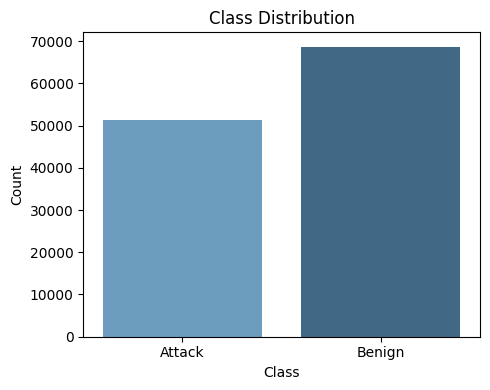

2026-04-18 20:13:18,088 INFO __main__ [EDA] Saved class distribution figure to artifacts/figures/eda_class_distribution.png
2026-04-18 20:13:18,088 INFO __main__ [EDA] Numeric columns available=80
2026-04-18 20:13:18,089 INFO __main__ [EDA] Correlation sample is large (120000), downsampling to 10000
2026-04-18 20:13:18,118 DEBUG matplotlib.colorbar locator: <matplotlib.ticker.AutoLocator object at 0x16b6d2e00>


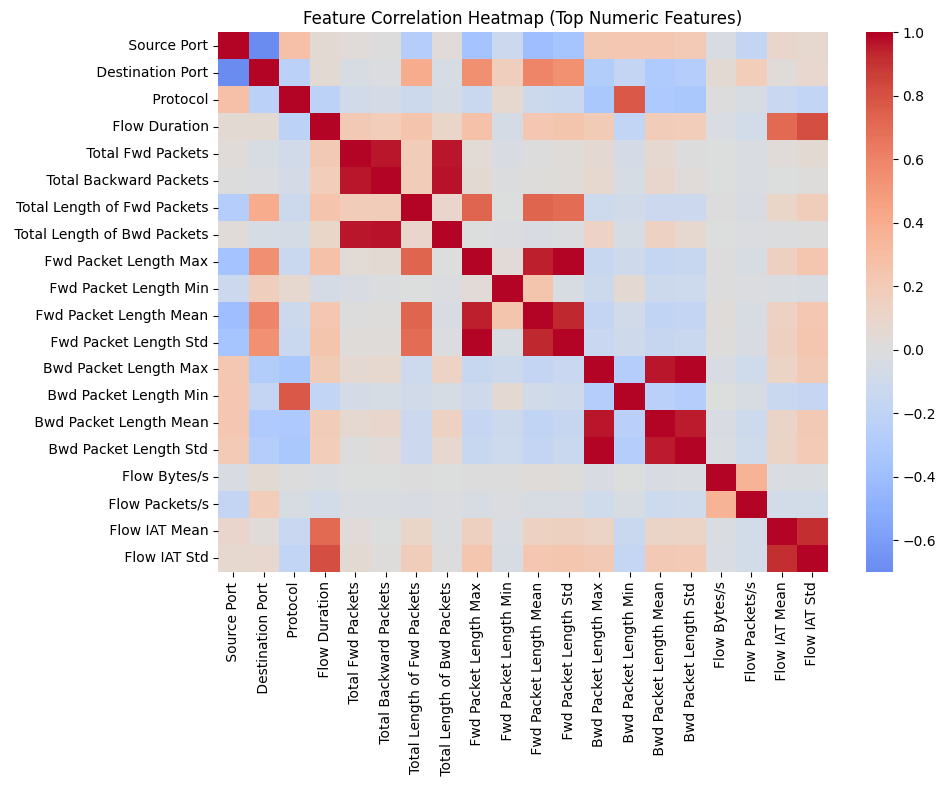

2026-04-18 20:13:18,270 INFO __main__ [EDA] Saved correlation heatmap to artifacts/figures/eda_correlation_heatmap.png
2026-04-18 20:13:18,371 INFO __main__ Split sizes -> train=84000 val=18000 test=18000
2026-04-18 20:13:18,374 INFO __main__ [RUN] Split complete: train=84000 val=18000 test=18000
2026-04-18 20:13:18,374 INFO __main__ Training baseline LogisticRegression model.
2026-04-18 20:13:19,370 INFO __main__ Baseline trained. threshold=0.880 metrics={'accuracy': 0.9999444444444444, 'precision': 1.0, 'recall': 0.9998701973001038, 'f1': 0.9999350944375933, 'roc_auc': 0.9999949319458665}
2026-04-18 20:13:19,370 INFO __main__ Training black-box RandomForest model (n_estimators=120, max_depth=20, min_samples_leaf=2).
2026-04-18 20:13:21,265 INFO __main__ Black-box trained. threshold=0.500 metrics={'accuracy': 0.9985, 'precision': 1.0, 'recall': 0.9964953271028038, 'f1': 0.9982445874780573, 'roc_auc': 0.9999245843287898}
2026-04-18 20:13:21,266 INFO __main__ [RUN] Training done. baseli

,model,split,accuracy,precision,recall,f1,roc_auc
0,baseline,train,0.999976,1.000000,0.999944,0.999972,0.999980
1,baseline,val,0.999944,1.000000,0.999870,0.999935,0.999995
2,baseline,test,1.000000,1.000000,1.000000,1.000000,1.000000
3,blackbox,train,0.998321,0.999944,0.996134,0.998035,0.999924
4,blackbox,val,0.998500,1.000000,0.996495,0.998245,0.999925
5,blackbox,test,0.997889,0.999870,0.995197,0.997528,0.999913


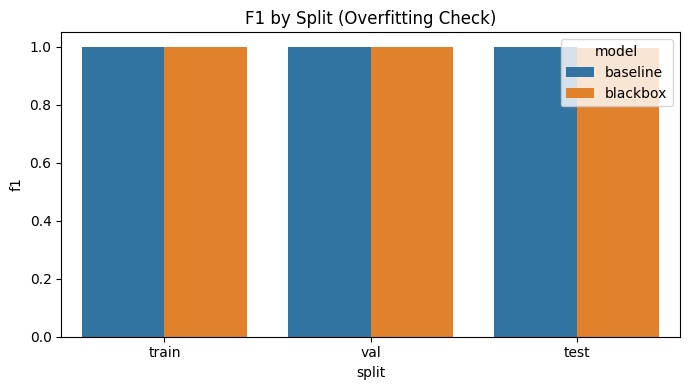

2026-04-18 20:13:22,709 INFO __main__ [RUN] Saved overfitting chart to artifacts/figures/overfitting_f1_by_split.png
2026-04-18 20:13:22,711 INFO __main__ [RUN] Saved model metrics table to artifacts/tables/model_metrics.csv


,model,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,1.000000,1.00000,1.000000,1.000000,1.000000
1,random_forest,0.997889,0.99987,0.995197,0.997528,0.999913


2026-04-18 20:13:22,713 INFO __main__ [PLOT] Building confusion matrix: Baseline Confusion Matrix
2026-04-18 20:13:22,722 DEBUG matplotlib.colorbar locator: <matplotlib.ticker.AutoLocator object at 0x16b870c90>


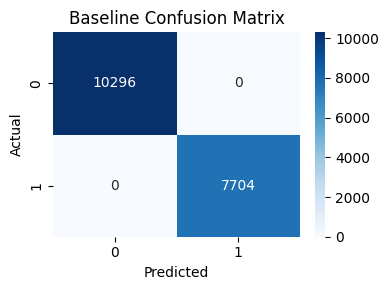

2026-04-18 20:13:22,765 INFO __main__ [PLOT] Saved confusion matrix to artifacts/figures/cm_baseline.png
2026-04-18 20:13:22,765 INFO __main__ [PLOT] Building confusion matrix: Black-box Confusion Matrix
2026-04-18 20:13:22,786 DEBUG matplotlib.colorbar locator: <matplotlib.ticker.AutoLocator object at 0x16b8bbe30>


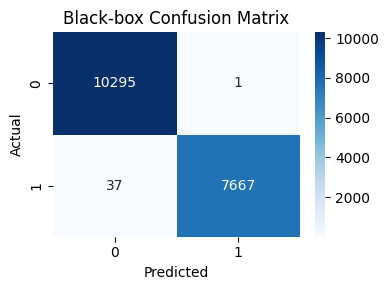

2026-04-18 20:13:22,860 INFO __main__ [PLOT] Saved confusion matrix to artifacts/figures/cm_blackbox.png
2026-04-18 20:13:22,862 INFO __main__ Selected 5 SOC cases.
2026-04-18 20:13:22,862 INFO __main__ Required case coverage after selection: {'TP': True, 'FP': True, 'FN': True}
2026-04-18 20:13:22,862 INFO __main__ [RUN] Selected case_ids=[0, 3006, 38, 1, 6] case_presence={'TP': True, 'FP': True, 'FN': True}
2026-04-18 20:13:22,863 INFO __main__ Starting explainability stage.
2026-04-18 20:13:24,383 INFO __main__ Running SHAP explainability for 5 samples (top_k=8).


In [ ]:
# End-to-end run (self-contained notebook pipeline)

def _load_main_dataset(
    path: str | None,
    label_col: str,
    max_rows: int | None = None,
    dataset_name: str | None = None,
    data_dir: str | None = None,
    class_balance_retry_cap: int | None = 300000,
) -> DatasetBundle:
    logger.info("[DATA] Start loading dataset path=%s max_rows=%s", path, max_rows)
    csv_candidates: list = []
    if path is not None:
        raw = None
        if dataset_name and data_dir:
            dataset_dir = Path(data_dir) / dataset_name
            csv_candidates = sorted(dataset_dir.rglob("*.csv")) if dataset_dir.exists() else []
            logger.info("[DATA] Candidate CSV files under %s: %d", dataset_dir, len(csv_candidates))
            if len(csv_candidates) > 1:
                frames = []
                loaded = 0
                for csv_path in csv_candidates:
                    remaining = None if max_rows is None else max_rows - loaded
                    if remaining is not None and remaining <= 0:
                        break
                    logger.info("[DATA] Reading %s with remaining rows=%s", csv_path, remaining)
                    chunk = load_csv(str(csv_path), nrows=remaining)
                    if chunk.empty:
                        logger.warning("[DATA] Skip empty CSV chunk: %s", csv_path)
                        continue
                    frames.append(chunk)
                    loaded += len(chunk)
                if frames:
                    raw = pd.concat(frames, ignore_index=True)
                    logger.info("[DATA] Concatenated %d CSV chunks; rows=%d", len(frames), len(raw))

        if raw is None:
            logger.info("[DATA] Falling back to single source read: %s", path)
            raw = load_csv(path, nrows=max_rows)
        logger.info("[DATA] Raw dataset shape=%s", raw.shape)

        bundle = unify_binary_labels(raw, label_col=label_col)
        if max_rows is not None and bundle.y.nunique() < 2:
            logger.warning("[DATA] Only one class detected after bounded load; retry with expanded scope.")
            if csv_candidates:
                frames = [load_csv(str(p), nrows=None) for p in csv_candidates]
                raw = pd.concat(frames, ignore_index=True)
                if class_balance_retry_cap is not None and len(raw) > class_balance_retry_cap:
                    logger.info("[DATA] Apply class_balance_retry_cap=%d", class_balance_retry_cap)
                    raw = raw.sample(n=class_balance_retry_cap, random_state=42)
            else:
                retry_rows = class_balance_retry_cap if class_balance_retry_cap is not None else None
                raw = load_csv(path, nrows=retry_rows)
            bundle = unify_binary_labels(raw, label_col=label_col)

        cleaned_X = basic_cleaning(bundle.X)
        logger.info("[DATA] Cleaned feature matrix shape=%s", cleaned_X.shape)
        return DatasetBundle(
            X=cleaned_X,
            y=bundle.y.loc[cleaned_X.index].reset_index(drop=True),
            attack_type=bundle.attack_type.loc[cleaned_X.index].reset_index(drop=True),
        )

    logger.warning("[DATA] No dataset path provided; using synthetic fallback dataset.")
    return build_synthetic_dataset()


def _save_confusion_matrix(cm, out_path: Path, title: str) -> None:
    logger.info("[PLOT] Building confusion matrix: %s", title)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    if SHOW_INLINE_PLOTS:
        plt.show()
    plt.savefig(out_path, dpi=150)
    plt.close()
    logger.info("[PLOT] Saved confusion matrix to %s", out_path)


def _generate_eda_outputs(bundle: DatasetBundle, figs_dir: Path, tables_dir: Path) -> None:
    logger.info("[EDA] Generating label distribution and correlation outputs.")
    label_counts = bundle.y.value_counts().rename(index={0: "Benign", 1: "Attack"}).sort_index()
    label_counts.to_csv(tables_dir / "eda_label_distribution.csv", header=["count"])
    logger.info("[EDA] Saved label distribution table to %s", tables_dir / "eda_label_distribution.csv")
    if SHOW_INLINE_TABLES:
        display(label_counts.rename("count").to_frame())

    plt.figure(figsize=(5, 4))
    sns.barplot(x=label_counts.index.tolist(), y=label_counts.values.tolist(), hue=label_counts.index.tolist(), palette="Blues_d", legend=False)
    plt.title("Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    if SHOW_INLINE_PLOTS:
        plt.show()
    plt.savefig(figs_dir / "eda_class_distribution.png", dpi=150)
    plt.close()
    logger.info("[EDA] Saved class distribution figure to %s", figs_dir / "eda_class_distribution.png")

    numeric_cols = bundle.X.select_dtypes(include=["number", "bool"]).columns.tolist()
    if numeric_cols:
        logger.info("[EDA] Numeric columns available=%d", len(numeric_cols))
        top_cols = numeric_cols[:20]
        corr_sample = bundle.X[top_cols]
        if len(corr_sample) > 10000:
            logger.info("[EDA] Correlation sample is large (%d), downsampling to 10000", len(corr_sample))
            corr_sample = corr_sample.sample(n=10000, random_state=42)
        corr = corr_sample.corr(numeric_only=True)
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, cmap="coolwarm", center=0.0)
        plt.title("Feature Correlation Heatmap (Top Numeric Features)")
        plt.tight_layout()
        if SHOW_INLINE_PLOTS:
            plt.show()
        plt.savefig(figs_dir / "eda_correlation_heatmap.png", dpi=150)
        plt.close()
        logger.info("[EDA] Saved correlation heatmap to %s", figs_dir / "eda_correlation_heatmap.png")


def run_topic_e() -> dict:
    start = time.perf_counter()
    if VERBOSE_LOGGING:
        # Keep notebook pipeline logs verbose without enabling every library's DEBUG logs.
        logger.setLevel(getattr(logging, LOG_LEVEL.upper(), logging.DEBUG))
        logging.getLogger("matplotlib").setLevel(logging.WARNING)
        logging.getLogger("matplotlib.font_manager").setLevel(logging.WARNING)
    logger.info("[RUN] Starting Topic E pipeline run.")
    logger.info(
        "[RUN] Config: DATA_DIR=%s CICIDS_PATH=%s MAX_ROWS=%s SAMPLE_SIZE=%s RF=(n_estimators=%s,max_depth=%s,min_leaf=%s) DISABLE_LIME=%s",
        DATA_DIR,
        CICIDS_PATH,
        MAX_ROWS,
        SAMPLE_SIZE,
        RF_N_ESTIMATORS,
        RF_MAX_DEPTH,
        RF_MIN_SAMPLES_LEAF,
        DISABLE_LIME,
    )

    max_rows = None if MAX_ROWS < 0 else MAX_ROWS
    rf_max_depth = None if RF_MAX_DEPTH < 0 else RF_MAX_DEPTH
    cb_cap = None if CLASS_BALANCE_RETRY_CAP < 0 else CLASS_BALANCE_RETRY_CAP

    out_dir = Path(OUTPUT_DIR)
    figs_dir = out_dir / "figures"
    tables_dir = out_dir / "tables"
    out_dir.mkdir(parents=True, exist_ok=True)
    figs_dir.mkdir(parents=True, exist_ok=True)
    tables_dir.mkdir(parents=True, exist_ok=True)
    logger.info("[RUN] Output directories ready: out=%s figs=%s tables=%s", out_dir.resolve(), figs_dir.resolve(), tables_dir.resolve())

    if LOG_FILE:
        fh = logging.FileHandler(LOG_FILE)
        fh.setFormatter(logging.Formatter("%(levelname)s %(name)s %(message)s"))
        logging.getLogger().addHandler(fh)

    data_root_for_discovery = DATA_DIR
    data_dir_path = Path(DATA_DIR)
    logger.info("[RUN] Resolve dataset root from DATA_DIR=%s", data_dir_path)
    # Support both project-root style DATA_DIR (e.g. .../data)
    # and direct CICIDS folder paths (e.g. .../data/cicids/TrafficLabelling).
    for parent in [data_dir_path, *data_dir_path.parents]:
        if parent.name.lower() == "cicids":
            data_root_for_discovery = str(parent.parent)
            break

    cicids_path = ensure_dataset_csv(
        dataset_name="cicids",
        data_root=data_root_for_discovery,
        preferred_path=CICIDS_PATH,
    )
    logger.info("[RUN] ensure_dataset_csv resolved path: %s", cicids_path)

    # Fallback: if DATA_DIR itself is a CSV folder, pick one CSV directly.
    if cicids_path is None and data_dir_path.exists() and data_dir_path.is_dir():
        direct_csvs = sorted(data_dir_path.glob("*.csv"))
        logger.info("[RUN] Direct CSV fallback candidates in DATA_DIR: %d", len(direct_csvs))
        if direct_csvs:
            cicids_path = str(direct_csvs[0])
            logger.info("[RUN] Fallback picked CSV: %s", cicids_path)

    if cicids_path is None:
        raise FileNotFoundError(
            f"No CICIDS CSV found under data directory '{DATA_DIR}'. "
            "Place extracted CSV files in data/cicids/ (or set CICIDS_PATH)."
        )

    bundle = _load_main_dataset(
        cicids_path,
        CICIDS_LABEL_COL,
        max_rows=max_rows,
        dataset_name="cicids",
        data_dir=data_root_for_discovery,
        class_balance_retry_cap=cb_cap,
    )
    logger.info("[RUN] Bundle loaded: X_shape=%s y_shape=%s", bundle.X.shape, bundle.y.shape)

    bundle = sample_dataset_bundle(bundle, sample_size=SAMPLE_SIZE)
    logger.info("[RUN] Bundle after sampling: X_shape=%s y_shape=%s", bundle.X.shape, bundle.y.shape)

    _generate_eda_outputs(bundle, figs_dir=figs_dir, tables_dir=tables_dir)
    X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(bundle.X, bundle.y)
    logger.info("[RUN] Split complete: train=%d val=%d test=%d", len(X_train), len(X_val), len(X_test))

    baseline = train_baseline(X_train, y_train, X_val, y_val)
    blackbox = train_blackbox(
        X_train,
        y_train,
        X_val,
        y_val,
        n_estimators=RF_N_ESTIMATORS,
        max_depth=rf_max_depth,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    )
    logger.info("[RUN] Training done. baseline_threshold=%.4f blackbox_threshold=%.4f", baseline.threshold, blackbox.threshold)

    baseline_test_metrics, baseline_cm, _ = evaluate_on_split(
        baseline.pipeline, baseline.threshold, X_test, y_test
    )
    blackbox_test_metrics, blackbox_cm, blackbox_probs = evaluate_on_split(
        blackbox.pipeline, blackbox.threshold, X_test, y_test
    )

    overfit_rows = []
    for model_name, model_artifacts in (("baseline", baseline), ("blackbox", blackbox)):
        for split_name, X_split, y_split in (
            ("train", X_train, y_train),
            ("val", X_val, y_val),
            ("test", X_test, y_test),
        ):
            split_metrics, _, _ = evaluate_on_split(
                model_artifacts.pipeline,
                model_artifacts.threshold,
                X_split,
                y_split,
            )
            overfit_rows.append({"model": model_name, "split": split_name, **split_metrics})
    overfit_df = pd.DataFrame(overfit_rows)
    overfit_df.to_csv(tables_dir / "overfitting_diagnostics.csv", index=False)
    logger.info("[RUN] Saved overfitting diagnostics table to %s", tables_dir / "overfitting_diagnostics.csv")
    if SHOW_INLINE_TABLES:
        display(overfit_df)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=overfit_df, x="split", y="f1", hue="model")
    plt.title("F1 by Split (Overfitting Check)")
    plt.tight_layout()
    if SHOW_INLINE_PLOTS:
        plt.show()
    plt.savefig(figs_dir / "overfitting_f1_by_split.png", dpi=150)
    plt.close()
    logger.info("[RUN] Saved overfitting chart to %s", figs_dir / "overfitting_f1_by_split.png")

    metrics_df = pd.DataFrame(
        [
            {"model": baseline.name, **baseline_test_metrics},
            {"model": blackbox.name, **blackbox_test_metrics},
        ]
    )
    metrics_df.to_csv(tables_dir / "model_metrics.csv", index=False)
    logger.info("[RUN] Saved model metrics table to %s", tables_dir / "model_metrics.csv")
    if SHOW_INLINE_TABLES:
        display(metrics_df)

    _save_confusion_matrix(baseline_cm, figs_dir / "cm_baseline.png", "Baseline Confusion Matrix")
    _save_confusion_matrix(blackbox_cm, figs_dir / "cm_blackbox.png", "Black-box Confusion Matrix")

    case_ids, forced_case_types, case_thresholds, case_presence = choose_required_soc_cases(
        y_true=y_test.reset_index(drop=True),
        y_prob=blackbox_probs,
        default_threshold=blackbox.threshold,
        max_cases=5,
    )
    case_threshold = float(np.mean(list(case_thresholds.values()))) if case_thresholds else float(blackbox.threshold)
    logger.info("[RUN] Selected case_ids=%s case_presence=%s", case_ids, case_presence)

    xai = run_explainability(
        blackbox.pipeline,
        X_train,
        X_test,
        sample_ids=case_ids,
        top_k=8,
        enable_lime=not DISABLE_LIME,
        plot_output_dir=str(figs_dir),
    )
    if xai.shap_global is not None:
        xai.shap_global.to_csv(tables_dir / "shap_global_importance.csv", index=False)
        logger.info("[RUN] Saved SHAP global importance to %s", tables_dir / "shap_global_importance.csv")
        if SHOW_INLINE_TABLES:
            display(xai.shap_global.head(20))
    if xai.shap_summary_plot:
        logger.info("[RUN] SHAP summary plot path: %s", xai.shap_summary_plot)
        print("SHAP summary:", xai.shap_summary_plot)
    if xai.shap_waterfall_plots:
        logger.info("[RUN] SHAP waterfall count: %d", len(xai.shap_waterfall_plots))
        print("SHAP waterfalls:", len(xai.shap_waterfall_plots), "files")

    case_report = build_soc_alert_report(
        y_true=y_test.reset_index(drop=True),
        y_prob=blackbox_probs,
        threshold=blackbox.threshold,
        shap_local=xai.shap_local_top_features,
        lime_local=xai.lime_local_top_features,
        case_ids=case_ids,
        forced_case_types=forced_case_types,
        case_thresholds=case_thresholds,
    )
    case_report.to_csv(tables_dir / "soc_alert_report.csv", index=False)
    logger.info("[RUN] Saved SOC alert report to %s", tables_dir / "soc_alert_report.csv")
    if SHOW_INLINE_TABLES:
        display(case_report)

    comparison_df = build_shap_lime_comparison_table(
        case_report=case_report,
        shap_local=xai.shap_local_top_features,
        lime_local=xai.lime_local_top_features,
        top_k=5,
    )
    comparison_df.to_csv(tables_dir / "shap_lime_case_comparison.csv", index=False)
    logger.info("[RUN] Saved SHAP/LIME comparison table to %s", tables_dir / "shap_lime_case_comparison.csv")
    if SHOW_INLINE_TABLES:
        display(comparison_df)

    analyst_metrics = compute_analyst_metrics(
        case_report,
        shap_local=xai.shap_local_top_features,
        lime_local=xai.lime_local_top_features,
    )

    summary = {
        "baseline_test_metrics": baseline_test_metrics,
        "blackbox_test_metrics": blackbox_test_metrics,
        "analyst_metrics": analyst_metrics,
        "cicids_path": cicids_path,
        "sample_size": SAMPLE_SIZE,
        "effective_rows": len(bundle.X),
        "case_threshold": case_threshold,
        "case_presence": case_presence,
        "output_dir": str(out_dir.resolve()),
        "elapsed_seconds": round(time.perf_counter() - start, 3),
    }
    (out_dir / "run_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    logger.info("[RUN] Saved summary JSON to %s", out_dir / "run_summary.json")
    logger.info("[RUN] Completed in %.2f seconds", time.perf_counter() - start)
    print(json.dumps(summary, indent=2))
    return summary


summary = run_topic_e()
summary
